In [1]:
!pip install datasets -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.layers import TextVectorization

In [4]:
train_data = load_dataset(
    "fancyzhx/amazon_polarity",
    split="train",
    streaming=True
)

test_data = load_dataset(
    "fancyzhx/amazon_polarity",
    split="test",
    streaming=True
)

train_data = train_data.take(10000)
test_data = test_data.take(2000)

train_data = list(train_data)
test_data = list(test_data)

print("Training reviews:", len(train_data))
print("Testing reviews:", len(test_data))

README.md:   0%|          | 0.00/6.81k [00:00<?, ?B/s]

Training reviews: 10000
Testing reviews: 2000


In [5]:
train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

print(train_df.head())

   label                                              title  \
0      1                     Stuning even for the non-gamer   
1      1              The best soundtrack ever to anything.   
2      1                                           Amazing!   
3      1                               Excellent Soundtrack   
4      1  Remember, Pull Your Jaw Off The Floor After He...   

                                             content  
0  This sound track was beautiful! It paints the ...  
1  I'm reading a lot of reviews saying that this ...  
2  This soundtrack is my favorite music of all ti...  
3  I truly like this soundtrack and I enjoy video...  
4  If you've played the game, you know how divine...  


In [6]:
train_df["review"] = train_df["title"] + " " + train_df["content"]

test_df["review"] = test_df["title"] + " " + test_df["content"]

print(train_df["review"].iloc[0])

Stuning even for the non-gamer This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^


In [7]:
print(train_df.shape)
print(test_df.shape)

print(train_df["label"].value_counts())

print(train_df[["review", "label"]].head())

(10000, 4)
(2000, 4)
label
0    5097
1    4903
Name: count, dtype: int64
                                              review  label
0  Stuning even for the non-gamer This sound trac...      1
1  The best soundtrack ever to anything. I'm read...      1
2  Amazing! This soundtrack is my favorite music ...      1
3  Excellent Soundtrack I truly like this soundtr...      1
4  Remember, Pull Your Jaw Off The Floor After He...      1


In [8]:
X_train = train_df["review"]
y_train = train_df["label"]

X_test = test_df["review"]
y_test = test_df["label"]

print(X_train.shape)
print(y_train.shape)

(10000,)
(10000,)


In [9]:
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(10000, 10000)
(2000, 10000)


In [10]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_prediction = nb_model.predict(X_test_tfidf)

nb_accuracy = accuracy_score(y_test, nb_prediction)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.809


In [11]:
print(classification_report(
    y_test,
    nb_prediction,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.78      0.83      0.81       954
    Positive       0.84      0.79      0.81      1046

    accuracy                           0.81      2000
   macro avg       0.81      0.81      0.81      2000
weighted avg       0.81      0.81      0.81      2000



In [12]:
svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

svm_prediction = svm_model.predict(X_test_tfidf)

svm_accuracy = accuracy_score(y_test, svm_prediction)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.8435


In [13]:
print(classification_report(
    y_test,
    svm_prediction,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.84      0.82      0.83       954
    Positive       0.84      0.86      0.85      1046

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



In [14]:
max_words = 10000
max_length = 100

vectorizer = TextVectorization(
    max_tokens=max_words,
    output_sequence_length=max_length
)

vectorizer.adapt(X_train)

X_train_lstm = vectorizer(np.array(X_train))
X_test_lstm = vectorizer(np.array(X_test))

print(X_train_lstm.shape)
print(X_test_lstm.shape)

(10000, 100)
(2000, 100)


In [15]:
lstm_model = Sequential()

lstm_model.add(
    Embedding(max_words, 64)
)

lstm_model.add(
    LSTM(32)
)

lstm_model.add(
    Dense(1, activation="sigmoid")
)

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = lstm_model.fit(
    X_train_lstm,
    y_train,
    epochs=2,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/2
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - accuracy: 0.5086 - loss: 0.6922 - val_accuracy: 0.5080 - val_loss: 0.6899
Epoch 2/2
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.7166 - loss: 0.5885 - val_accuracy: 0.7015 - val_loss: 0.5920


In [17]:
lstm_result = lstm_model.predict(X_test_lstm)

lstm_prediction = (lstm_result > 0.5).astype(int)

lstm_accuracy = accuracy_score(
    y_test,
    lstm_prediction
)

print("LSTM Accuracy:", lstm_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step
LSTM Accuracy: 0.701


In [18]:
print(classification_report(
    y_test,
    lstm_prediction,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.82      0.48      0.60       954
    Positive       0.65      0.91      0.76      1046

    accuracy                           0.70      2000
   macro avg       0.74      0.69      0.68      2000
weighted avg       0.73      0.70      0.69      2000



In [19]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "SVM",
        "LSTM"
    ],

    "Accuracy": [
        nb_accuracy,
        svm_accuracy,
        lstm_accuracy
    ]
})

print(results)

         Model  Accuracy
0  Naive Bayes    0.8090
1          SVM    0.8435
2         LSTM    0.7010


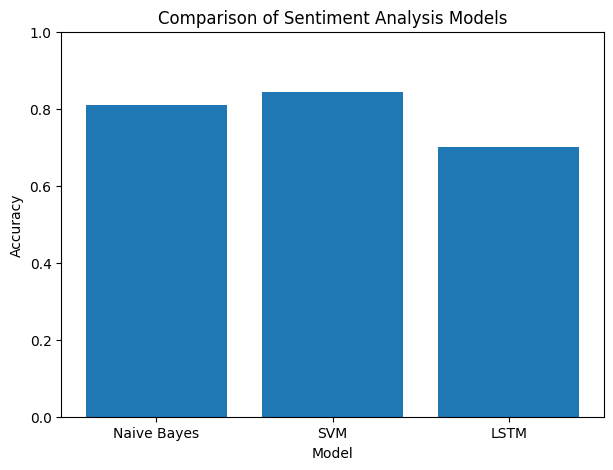

In [20]:
plt.figure(figsize=(7,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Comparison of Sentiment Analysis Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.show()

In [21]:
cm_nb = confusion_matrix(y_test, nb_prediction)

print("Naive Bayes Confusion Matrix")
print(cm_nb)

Naive Bayes Confusion Matrix
[[793 161]
 [221 825]]


In [22]:
cm_svm = confusion_matrix(y_test, svm_prediction)

print("SVM Confusion Matrix")
print(cm_svm)

SVM Confusion Matrix
[[787 167]
 [146 900]]


In [23]:
cm_lstm = confusion_matrix(
    y_test,
    lstm_prediction
)

print("LSTM Confusion Matrix")
print(cm_lstm)

LSTM Confusion Matrix
[[454 500]
 [ 98 948]]


In [24]:
review = ["This product is amazing and I really love it"]

review_tfidf = tfidf.transform(review)

result = nb_model.predict(review_tfidf)

if result[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")

Positive Review


In [25]:
review = ["This product is terrible and completely useless"]

review_tfidf = tfidf.transform(review)

result = nb_model.predict(review_tfidf)

if result[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")

Negative Review


In [26]:
review = ["This product is amazing and I really love it"]

review_tfidf = tfidf.transform(review)

result = svm_model.predict(review_tfidf)

if result[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")

Positive Review


In [27]:
review = ["This product is amazing and I really love it"]

review_vector = vectorizer(np.array(review))

result = lstm_model.predict(review_vector)

if result[0][0] > 0.5:
    print("Positive Review")
else:
    print("Negative Review")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Positive Review


In [28]:
results = pd.DataFrame({
    "Model": ["Naive Bayes", "SVM", "LSTM"],
    "Accuracy": [
        nb_accuracy,
        svm_accuracy,
        lstm_accuracy
    ]
})

print(results)

         Model  Accuracy
0  Naive Bayes    0.8090
1          SVM    0.8435
2         LSTM    0.7010


In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

nb_precision = precision_score(y_test, nb_prediction)
nb_recall = recall_score(y_test, nb_prediction)
nb_f1 = f1_score(y_test, nb_prediction)

svm_precision = precision_score(y_test, svm_prediction)
svm_recall = recall_score(y_test, svm_prediction)
svm_f1 = f1_score(y_test, svm_prediction)

lstm_precision = precision_score(y_test, lstm_prediction)
lstm_recall = recall_score(y_test, lstm_prediction)
lstm_f1 = f1_score(y_test, lstm_prediction)

results = pd.DataFrame({
    "Model": ["Naive Bayes", "SVM", "LSTM"],
    "Accuracy": [nb_accuracy, svm_accuracy, lstm_accuracy],
    "Precision": [nb_precision, svm_precision, lstm_precision],
    "Recall": [nb_recall, svm_recall, lstm_recall],
    "F1 Score": [nb_f1, svm_f1, lstm_f1]
})

print(results)

         Model  Accuracy  Precision    Recall  F1 Score
0  Naive Bayes    0.8090   0.836714  0.788719  0.812008
1          SVM    0.8435   0.843486  0.860421  0.851869
2         LSTM    0.7010   0.654696  0.906310  0.760225


In [30]:
results.to_csv("model_results.csv", index=False)

print("Results saved successfully.")

Results saved successfully.


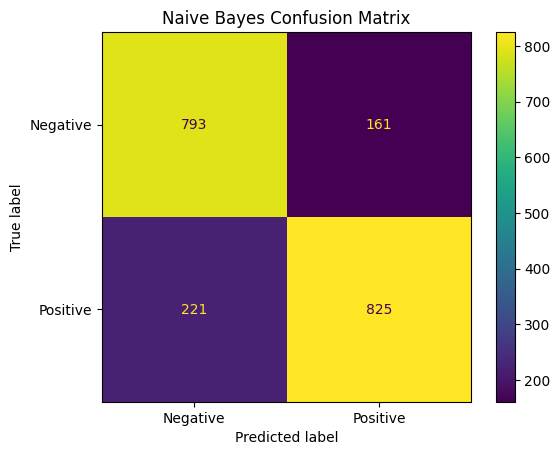

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    nb_prediction,
    display_labels=["Negative", "Positive"]
)

plt.title("Naive Bayes Confusion Matrix")
plt.show()

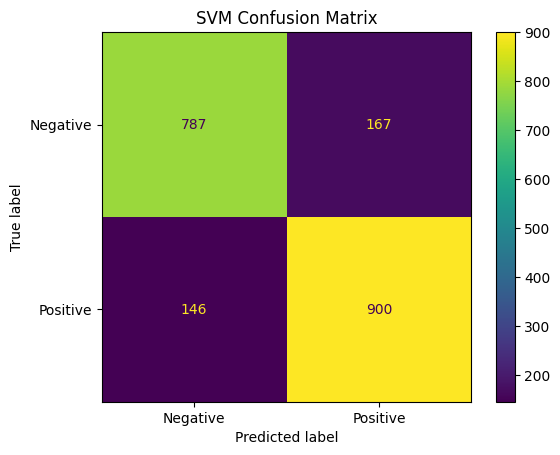

In [32]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_prediction,
    display_labels=["Negative", "Positive"]
)

plt.title("SVM Confusion Matrix")
plt.show()

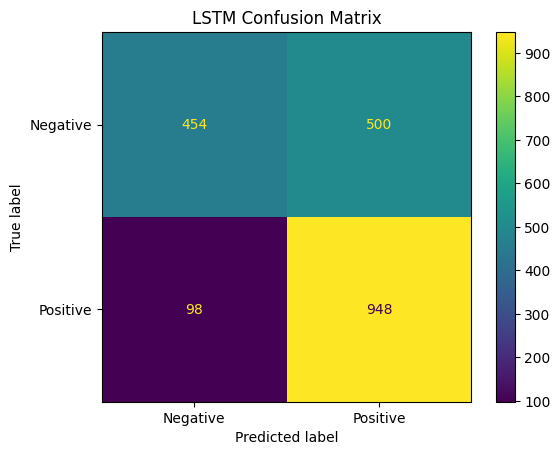

In [33]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lstm_prediction,
    display_labels=["Negative", "Positive"]
)

plt.title("LSTM Confusion Matrix")
plt.show()

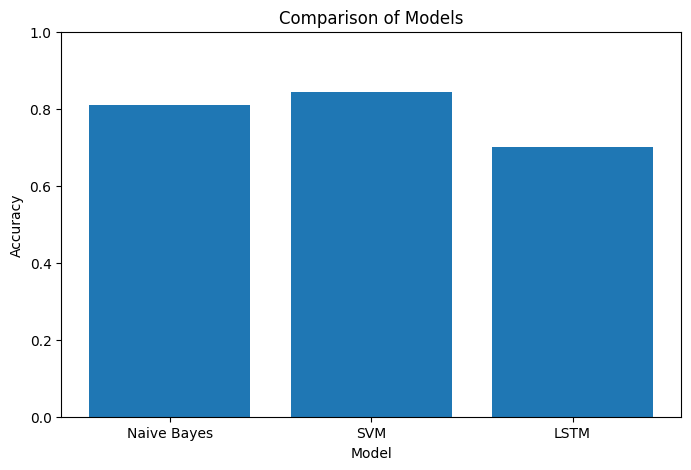

In [34]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Comparison of Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.show()